# CRAG: Corrective RAG

이번 튜토리얼은 **Corrective RAG (CRAG)** 전략을 사용하여 RAG 기반 시스템을 개선하는 방법을 다룹니다.

CRAG는 검색된 문서들에 대한 자기 반성(self-reflection) 및 자기 평가(self-evaluation) 단계를 포함하여, 검색-생성 파이프라인을 정교하게 다루는 접근법입니다.

![crag](./assets/langgraph-crag.png)

---

**CRAG란?**

**Corrective-RAG (CRAG)**는 RAG 전략에서 **검색 과정에서 찾아온 문서를 평가하고, 지식을 정제(refine) 하는 단계를 추가한 방법론**입니다.

CRAG의 핵심 아이디어 ([논문 링크](https://arxiv.org/pdf/2401.15884.pdf)):

1. 검색된 문서 중 하나 이상이 관련성 임계값을 초과하면 생성 단계로 진행
2. 생성 전에 지식 정제 단계를 수행
3. 문서를 "knowledge strips"로 세분화하여 평가
4. 모든 문서가 관련성 임계값 이하이면 웹 검색으로 보강
5. 웹 검색 시 쿼리 재작성(Query-Rewrite)을 통해 검색 결과 최적화

---

**참고**

- [LangGraph CRAG 튜토리얼 (공식 문서)](https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_crag_local/)

## 환경 설정

CRAG 튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 기능을 활성화하여 LangSmith에서 각 노드의 실행 과정을 추적할 수 있도록 합니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-RAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-RAG


## PDF 기반 Retrieval Chain 생성

CRAG 파이프라인의 첫 번째 단계는 문서를 검색하는 Retriever를 준비하는 것입니다. `PDFRetrievalChain`을 사용하여 PDF 문서를 로드하고, 벡터 스토어 기반의 검색기(retriever)와 RAG 체인을 생성합니다. 이렇게 생성된 retriever는 이후 그래프의 검색 노드에서 사용됩니다.

아래 코드는 PDF 문서를 로드하고 retriever와 chain을 생성합니다.

In [3]:
from rag.pdf import PDFRetrievalChain

# PDF 문서를 로드합니다.
pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

# retriever와 chain을 생성합니다.
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

Cache configured for multi-PDF processing
Loading PDF: data/SPRI_AI_Brief_2023년12월호_F.pdf
Successfully loaded 23 pages from: data/SPRI_AI_Brief_2023년12월호_F.pdf

Loading Summary:
- Successfully loaded: 1 files
- Failed to load: 0 files
- Total documents loaded: 23
FAISS index saved to cache


## 검색된 문서의 관련성 평가 (Retrieval Grader)

CRAG의 핵심은 검색된 문서가 질문과 실제로 관련이 있는지 평가하는 단계입니다. LLM을 활용하여 각 문서의 관련성을 'yes' 또는 'no'로 이진 분류합니다. `with_structured_output()`을 사용하면 Pydantic 모델 기반으로 LLM의 출력을 구조화할 수 있어, 평가 결과를 프로그래밍적으로 처리하기 용이합니다.

아래 코드는 문서 관련성 평가기(Retrieval Grader)를 생성합니다.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field


# 관련성 평가를 위한 데이터 모델
class GradeDocuments(BaseModel):
    """검색된 문서의 관련성을 평가하는 이진 점수입니다."""

    binary_score: str = Field(
        description="문서가 질문과 관련이 있으면 'yes', 없으면 'no'"
    )


# LLM 초기화
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능합니다.
llm = init_chat_model("claude-sonnet-4-5", temperature=0)
# 구조화된 출력을 생성하는 LLM
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 시스템 프롬프트 정의
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

# 프롬프트 템플릿 생성
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

# Retrieval 평가기 생성
retrieval_grader = grade_prompt | structured_llm_grader

### 평가기 테스트

생성한 Retrieval Grader가 올바르게 동작하는지 확인합니다. 질문을 정의하고 PDF에서 문서를 검색한 후, 검색된 문서 중 하나를 선택하여 관련성 평가를 수행합니다. 평가 결과는 `binary_score` 필드에 'yes' 또는 'no'로 반환됩니다.

아래 코드는 검색된 문서의 관련성 평가를 테스트합니다.

In [5]:
# 질문 정의
question = "삼성전자가 개발한 생성AI 에 대해 설명하세요."

# 문서 검색
docs = pdf_retriever.invoke(question)

# 검색된 문서 중 1번 index 문서의 관련성 평가
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


## 답변 생성 체인 (RAG Chain)

관련성 평가를 통과한 문서들을 컨텍스트로 사용하여 최종 답변을 생성하는 RAG 체인을 구성합니다. LangChain Hub에서 RAG 전용 프롬프트를 가져오고, LLM과 출력 파서를 연결하여 체인을 생성합니다. `format_docs()` 함수를 통해 문서를 XML 형식으로 포맷팅하여 출처(source)와 페이지 정보를 함께 전달합니다.

아래 코드는 RAG 체인을 생성하고 테스트를 수행합니다.

In [ ]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser

from langchain_core.output_parsers import StrOutputParser

# LangChain Hub에서 프롬프트 가져오기
prompt = Client().pull_prompt("teddynote/rag-prompt")

# LLM 초기화
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능합니다.
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

# 문서 포맷팅 함수
def format_docs(docs):
    """문서 리스트를 포맷팅된 문자열로 변환합니다."""
    return "\n\n".join(
        [
            f'<document><content>{doc.page_content}</content><source>{doc.metadata["source"]}</source><page>{doc.metadata["page"]+1}</page></document>'
            for doc in docs
        ]
    )


# RAG 체인 생성
rag_chain = prompt | llm | StrOutputParser()

# 체인 실행 테스트
generation = rag_chain.invoke({"context": format_docs(docs), "question": question})
print(generation)

삼성전자가 개발한 생성AI '삼성 가우스(Samsung Gauss)'는 2023년 11월 8일 '삼성 AI 포럼 2023'에서 최초 공개되었습니다. 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본떠 명명되었으며, 다음과 같은 특징을 가지고 있습니다:

**구성**: 언어 모델(텍스트 생성), 코드 모델(코드 생성), 이미지 모델(이미지 생성)의 3개 모델로 구성

**주요 특징**:
- 온디바이스에서 작동 가능하여 외부로 사용자 정보가 유출될 위험이 없음
- 다양한 상황에 최적화된 크기의 모델 선택 가능
- 라이선스나 개인정보를 침해하지 않는 안전한 데이터로 학습

**기능**:
- 언어 모델: 메일 작성, 문서 요약, 번역 업무 지원
- 코드 모델: AI 코딩 어시스턴트 '코드아이(code.i)'로 대화형 인터페이스 제공, 사내 소프트웨어 개발에 최적화
- 이미지 모델: 창의적 이미지 생성, 기존 이미지 변환, 저해상도 이미지의 고해상도 전환 지원

삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획입니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (page 13)


## 쿼리 재작성 (Question Re-writer)

CRAG에서 모든 검색 문서가 관련성이 없다고 판단되면, 원래 질문을 웹 검색에 최적화된 형태로 재작성합니다. 이를 통해 웹 검색의 정확도를 높이고, 사용자의 의도에 더 부합하는 결과를 얻을 수 있습니다. LLM이 질문의 의미적 의도를 분석하여 개선된 질문을 생성합니다.

아래 코드는 Question Re-writer 체인을 생성합니다.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LLM 설정
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능합니다.
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

# Query Rewrite 시스템 프롬프트
system = """You a question re-writer that converts an input question to a better version that is optimized 
for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

# 프롬프트 정의
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

# Question Re-writer 체인 생성
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [8]:
# 쿼리 재작성 테스트
print(f'[원본 질문]: "{question}"')
print("[쿼리 재작성]:", question_rewriter.invoke({"question": question}))

[원본 질문]: "삼성전자가 개발한 생성AI 에 대해 설명하세요."
[쿼리 재작성]: Here's an improved version optimized for web search:

**Improved Question:**
"What is Samsung Electronics' generative AI technology? Describe Samsung's developed generative AI models, features, and applications."

**Alternative search-optimized versions:**

1. "Samsung Electronics generative AI development - Samsung Gauss AI model features and capabilities"

2. "삼성전자 생성형 AI 기술 - Samsung Gauss (삼성 가우스) 특징 및 활용 사례"

**Reasoning:**
- Added specificity by mentioning "Samsung Gauss" (삼성 가우스), which is Samsung's actual generative AI platform
- Included English terms for broader search results
- Added context words like "technology," "models," "features," and "applications" to capture comprehensive information
- Provided both English and Korean versions since Samsung is a Korean company and relevant information may exist in both languages
- Made the question more structured to retrieve specific details rather than general information


## 웹 검색 도구

PDF 문서에서 관련 정보를 찾지 못한 경우, 웹 검색을 통해 보완적인 정보를 수집합니다. `TavilySearch`는 AI 에이전트에 최적화된 웹 검색 API로, 검색 결과를 구조화된 형태로 반환합니다. `max_results` 매개변수로 반환할 최대 검색 결과 수를 설정할 수 있습니다.

아래 코드는 웹 검색 도구를 생성하고 테스트합니다.

In [9]:
from langchain_teddynote.tools.tavily import TavilySearch

# 웹 검색 도구 생성 (최대 3개 결과)
web_search_tool = TavilySearch(max_results=3)

In [10]:
# 웹 검색 테스트
results = web_search_tool.invoke({"query": question})
print(results)

[{'url': 'https://www.esgeconomy.com/news/articleView.html?idxno=5090', 'title': "삼성전자, 자체 개발한 생성형 AI '삼성 가우스' 첫 공개", 'content': '### 삼성전자, 자체 개발한 생성형 AI \'삼성 가우스\' 첫 공개. 삼성전자가 자체 개발한 생성형 AI \'삼성 가우스\'. [ESG경제=김도산 기자] 삼성전자가 자체 개발한 생성형 인공지능(AI) 모델 \'삼성 가우스(Samsung Gauss)‘를 처음 공개했다. 삼성전자는 삼성 가우스를 활용해 임직원의 업무 생산성을 높이고, 생성형 AI 모델을 단계적으로 제품에 탑재해 새로운 사용자 경험을 제공한다는 계획이다. 삼성전자는 8일 삼성전자 서울R&D캠퍼스에서 \'삼성 AI 포럼 2023\' 2일차 행사를 열고 삼성리서치에서 개발한 삼성 가우스를 처음으로 공개했다고 밝혔다. 삼성전자는 챗GPT 등 외부 생성형 AI 사용 확대로 보안 우려가 커지자. 삼성전자는 생성형 AI 모델들을 다양한 제품에 단계적으로 탑재할 계획인데, 업계에서는 이르면 내년 1월 공개할 갤럭시 S24에 생성형 AI 기능이 탑재될 것으로 보고 있다. ‘삼성 AI 포럼 2023’을 알리는 포스터. 한편 삼성리서치에서 주관한 이날 ’\'삼성 AI 포럼 2023\' 포럼에는 삼성전자의 AI 연구 인력과 학계·업계 AI 전문가 150여명이 참석해 생성형 AI 기술의 발전 방향을 논의하고 최신 기술 동향을 공유했다. 김대현 삼성리서치 글로벌AI센터 부센터장(부사장)은 "삼성전자는 AI 기술 개발뿐만 아니라 AI 활용 시 보안과 안전성을 확보하기 위해 \'AI 윤리 원칙\'을 정해 이를 준수하기 위해 노력하고 있다"며 "생성형 AI에 대한 지속적 연구를 통해 소비자의 경험 가치를 높여 나갈 계획"이라고 말했다.', 'score': 0.8361405, 'raw_content': '## 상단영역\n\n# [ESG경제](https://www.esgeconomy.com)\n\n

## State 정의

LangGraph에서 그래프의 상태(State)는 노드 간에 공유되는 데이터 구조입니다. `TypedDict`를 사용하여 상태를 정의하며, 각 필드는 그래프 실행 중 노드들이 읽고 업데이트하는 값입니다. CRAG 그래프에서는 질문, 생성된 답변, 웹 검색 필요 여부, 검색된 문서 리스트를 상태로 관리합니다.

아래 코드는 CRAG 그래프의 상태를 정의합니다.

In [11]:
from typing import Annotated, List
from typing_extensions import TypedDict


# 상태 정의 (TypedDict 기반 - LangGraph v1 호환)
class GraphState(TypedDict):
    question: Annotated[str, "질문"]
    generation: Annotated[str, "생성된 답변"]
    web_search: Annotated[str, "웹 검색 필요 여부 (yes/no)"]
    documents: Annotated[List[str], "검색된 문서 리스트"]

## 노드 정의

CRAG 그래프를 구성하는 각 노드를 함수로 정의합니다. 각 노드는 상태(State)를 입력으로 받아 처리한 후, 업데이트할 상태 값을 딕셔너리로 반환합니다. CRAG 파이프라인은 문서 검색(`retrieve`), 답변 생성(`generate`), 문서 평가(`grade_documents`), 쿼리 재작성(`query_rewrite`), 웹 검색(`web_search`) 총 5개의 노드로 구성됩니다.

아래 코드는 각 노드 함수를 정의합니다.

In [12]:
from langchain_core.documents import Document

def retrieve(state: GraphState):
    """문서를 검색하는 노드입니다."""
    print("\n==== RETRIEVE ====\n")
    question = state["question"]

    # 문서 검색 수행
    documents = pdf_retriever.invoke(question)
    return {"documents": documents}


def generate(state: GraphState):
    """답변을 생성하는 노드입니다."""
    print("\n==== GENERATE ====\n")
    question = state["question"]
    documents = state["documents"]

    # RAG를 사용한 답변 생성
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"generation": generation}


def grade_documents(state: GraphState):
    """검색된 문서의 관련성을 평가하는 노드입니다."""
    print("\n==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====\n")
    question = state["question"]
    documents = state["documents"]

    # 필터링된 문서 리스트
    filtered_docs = []
    relevant_doc_count = 0

    for d in documents:
        # Question-Document 관련성 평가
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score

        if grade == "yes":
            print("==== [GRADE: DOCUMENT RELEVANT] ====")
            filtered_docs.append(d)
            relevant_doc_count += 1
        else:
            print("==== [GRADE: DOCUMENT NOT RELEVANT] ====")
            continue

    # 관련 문서가 없으면 웹 검색 수행
    web_search = "Yes" if relevant_doc_count == 0 else "No"
    return {"documents": filtered_docs, "web_search": web_search}


def query_rewrite(state: GraphState):
    """쿼리를 재작성하는 노드입니다."""
    print("\n==== [REWRITE QUERY] ====\n")
    question = state["question"]

    # 질문 재작성
    better_question = question_rewriter.invoke({"question": question})
    return {"question": better_question}


def web_search(state: GraphState):
    """웹 검색을 수행하는 노드입니다."""
    print("\n==== [WEB SEARCH] ====\n")
    question = state["question"]
    documents = state["documents"]

    # 웹 검색 수행 (Tavily API 쿼리 길이 제한: 400자)
    query = question[:400]
    docs = web_search_tool.invoke({"query": query})
    
    # 검색 결과를 문서 형식으로 변환
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents}

## 조건부 엣지 함수

조건부 엣지(Conditional Edge)는 현재 상태에 따라 다음에 실행할 노드를 동적으로 결정합니다. CRAG에서는 문서 관련성 평가 결과에 따라 두 가지 경로로 분기합니다. 관련 문서가 있으면 바로 답변을 생성하고, 관련 문서가 없으면 쿼리를 재작성하여 웹 검색을 수행합니다.

아래 코드는 문서 평가 결과에 따른 라우팅 함수를 정의합니다.

In [13]:
def decide_to_generate(state: GraphState):
    """평가 결과에 따라 다음 단계를 결정하는 함수입니다."""
    print("==== [ASSESS GRADED DOCUMENTS] ====")
    web_search = state["web_search"]

    if web_search == "Yes":
        # 웹 검색이 필요한 경우
        print(
            "==== [DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, QUERY REWRITE] ===="
        )
        return "query_rewrite"
    else:
        # 관련 문서가 있으면 답변 생성
        print("==== [DECISION: GENERATE] ====")
        return "generate"

## 그래프 생성

앞서 정의한 노드와 엣지를 조합하여 CRAG 그래프를 생성합니다. `StateGraph`에 노드를 추가하고, `add_edge()`로 순차 연결, `add_conditional_edges()`로 조건부 분기를 설정합니다. 최종적으로 `compile()`을 호출하여 실행 가능한 그래프 객체를 생성합니다.

아래 코드는 CRAG 그래프를 생성하고 컴파일합니다.

In [14]:
from langgraph.graph import END, StateGraph, START

# 그래프 상태 초기화
workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("query_rewrite", query_rewrite)
workflow.add_node("web_search_node", web_search)

# 엣지 연결
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")

# 문서 평가 후 조건부 엣지
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "query_rewrite": "query_rewrite",
        "generate": "generate",
    },
)

workflow.add_edge("query_rewrite", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# 그래프 컴파일
app = workflow.compile()

### 그래프 시각화

컴파일된 그래프의 노드와 엣지 구조를 시각적으로 확인합니다. `visualize_graph()`를 사용하면 CRAG 파이프라인의 전체 실행 흐름을 한눈에 파악할 수 있습니다. 검색 → 문서 평가 → 조건부 분기(답변 생성 또는 쿼리 재작성 → 웹 검색)의 흐름이 표시됩니다.

아래 코드는 CRAG 그래프를 시각화합니다.

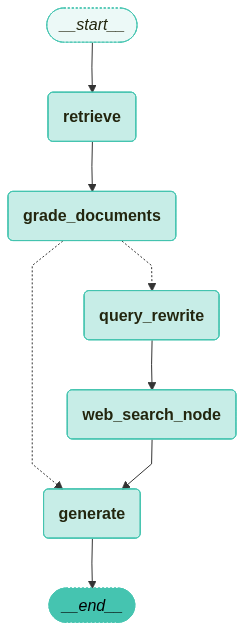

In [15]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(app)

## 그래프 실행

완성된 CRAG 그래프를 실행하여 결과를 확인합니다. 두 가지 시나리오로 테스트합니다. 첫 번째는 PDF 문서에서 답변 가능한 질문으로 문서 검색 → 답변 생성 경로를 확인하고, 두 번째는 PDF에 없는 정보를 질문하여 쿼리 재작성 → 웹 검색 경로가 올바르게 동작하는지 확인합니다.

아래 코드는 문서 검색이 가능한 질문으로 그래프를 실행합니다.

In [16]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, invoke_graph, random_uuid

# config 설정
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

# 질문 입력 (문서에서 검색 가능한 질문)
inputs = {
    "question": "삼성전자가 개발한 생성형 AI 의 이름은?",
}

# 스트리밍 실행
stream_graph(
    app,
    inputs,
    config,
    node_names=["retrieve", "grade_documents", "query_rewrite", "web_search_node", "generate"],
)


==== RETRIEVE ====


==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====


🔄 Node: grade_documents 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [GRADE: DOCUMENT RELEVANT] ====
==== [GRADE: DOCUMENT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [ASSESS GRADED DOCUMENTS] ====
==== [DECISION: GENERATE] ====

==== GENERATE ====


🔄 Node: generate 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
삼성전자가 개발한 생성형 AI의 이름은 **삼성 가우스(Samsung Gauss)**입니다. 이는 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본떠 명명되었으며, 언어 모델, 코드 모델, 이미지 모델의 3개 모델로 구성되어 있습니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (page 12)

In [17]:
# 질문 입력 (문서에 없는 정보 - 웹 검색 필요)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

inputs = {
    "question": "2024년 노벨문학상 수상자의 이름은?",
}

In [18]:
# 그래프 실행
invoke_graph(app, inputs, config)


==== RETRIEVE ====


🔄 Node: retrieve 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
page_content='▹ 빌 게이츠, AI 에이전트로 인한 컴퓨터 사용의 패러다임 변화 전망································13
▹ 유튜브, 2024년부터 AI 생성 콘텐츠 표시 의무화····························································14
3. 기술/연구
▹ 영국 과학혁신기술부, AI 안전 연구소 설립 발표······························································15
▹ 구글 딥마인드, 범용 AI 모델의 기능과 동작에 대한 분류 체계 발표······························16
▹ 갈릴레오의 LLM 환각 지수 평가에서 GPT-4가 가장 우수 ···········································17
4. 인력/교육
▹ 영국 옥스퍼드 인터넷 연구소, AI 기술자의 임금이 평균 21% 높아·······························18
Ⅱ
. 주요 행사
▹CES 2024·····························································································································19
▹AIMLA 2024·························································································································19
▹AAAI Conference on Artificial Intelligence····························································

In [19]:
# 스트리밍 실행
stream_graph(
    app,
    inputs,
    config,
    node_names=["retrieve", "grade_documents", "query_rewrite", "generate"],
)


==== RETRIEVE ====


==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====


🔄 Node: grade_documents 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [ASSESS GRADED DOCUMENTS] ====
==== [DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, QUERY REWRITE] ====

==== [REWRITE QUERY] ====


🔄 Node: query_rewrite 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Here's an improved version optimized for web search:

**Improved question:**
"Who won the 2024 Nobel Prize in Literature?"

**Alternative search queries:**
- "2024 Nobel Literature Prize winner"
- "Nobel Prize in Literature 2024 recipient name"
- "2024 노벨 문학상 수상자" (Korean version for Korean sources)



## 정리

이 튜토리얼에서는 **CRAG(Corrective RAG)** 전략을 구현했습니다.

### 핵심 개념

1. **문서 관련성 평가**: 검색된 각 문서의 질문에 대한 관련성을 평가합니다.
2. **조건부 웹 검색**: 관련 문서가 없으면 쿼리를 재작성하고 웹 검색을 수행합니다.
3. **자기 수정**: 검색 결과를 평가하고 필요시 보완하는 자기 수정 메커니즘입니다.

### 다음 단계

다음 튜토리얼에서는 **Self-RAG**를 구현하여 답변의 환각(hallucination)을 검증하는 방법을 학습합니다.